# Movie Data Cleaning & Analysis

**Python | Pandas | NumPy | Data Cleaning | Exploratory Data Analysis**

## Project Overview

This project explores a large movie dataset to demonstrate practical data cleaning, transformation, and exploratory analysis techniques using Python.

The analysis focuses on preparing raw movie data, handling missing and duplicate records, examining movie characteristics, and calculating financial metrics such as movie profit.

## Dataset

The dataset contains information about thousands of movies, including:

- Movie title
- Release date
- Original language
- Genres
- Budget
- Revenue
- Runtime
- Ratings

The dataset was provided as part of a data science course project and was used for practicing real-world data preparation and analysis.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Exploration

The first step is to load the movie dataset and inspect its structure. This helps identify the available variables, dataset size, and potential data-quality issues before beginning the analysis.

In [32]:
# Load the dataset
df = pd.read_csv("movies_metadata.csv").dropna(axis=1, how="all")

# Display the first five rows
df.head()

pd.read_csv("movies_metadata.csv")

,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,...,status,tagline,title,video,vote_average,vote_count,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862.0,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,...,Released,NaN,Toy Story,False,7.7,5415.0,NaN,NaN,NaN,NaN
1,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844.0,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,...,Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,NaN,NaN,NaN,NaN
2,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602.0,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,...,Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,NaN,NaN,NaN,NaN
3,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357.0,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,...,Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,NaN,NaN,NaN,NaN
4,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862.0,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,...,Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45448,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050.0,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,0.072051,...,Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,NaN,NaN,NaN,NaN
45449,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109.0,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,0.178241,...,Released,NaN,Century of Birthing,False,9.0,3.0,NaN,NaN,NaN,NaN
45450,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758.0,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",0.903007,...,Released,A deadly game of wits.,Betrayal,False,3.8,6.0,NaN,NaN,NaN,NaN
45451,NaN,0,[],NaN,227506.0,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",0.003503,...,Released,NaN,Satan Triumphant,False,0.0,0.0,NaN,NaN,NaN,NaN


In [33]:
# Examine the dataset dimensions and columns
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (45453, 23)

Columns:
['belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']


## 2. Data Cleaning

Before analyzing the movie data, I selected the variables relevant to this project and examined the dataset for duplicate and incomplete records.

Cleaning the data helps ensure that the results are based on consistent and usable records.

In [34]:
cols = [
    "id",
    "title",
    "release_date",
    "original_language",
    "genres",
    "budget",
    "revenue",
    "runtime",
    "vote_count",
    "vote_average"
]

df_clean = df[cols].copy()

df_clean.head()

,id,title,release_date,original_language,genres,budget,revenue,runtime,vote_count,vote_average
0,862.0,Toy Story,1995-10-30,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",30000000,373554033.0,81.0,5415.0,7.7
1,8844.0,Jumanji,1995-12-15,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",65000000,262797249.0,104.0,2413.0,6.9
2,15602.0,Grumpier Old Men,1995-12-22,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0,0.0,101.0,92.0,6.5
3,31357.0,Waiting to Exhale,1995-12-22,en,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",16000000,81452156.0,127.0,34.0,6.1
4,11862.0,Father of the Bride Part II,1995-02-10,en,"[{'id': 35, 'name': 'Comedy'}]",0,76578911.0,106.0,173.0,5.7


### Duplicate Records

Duplicate rows can cause individual movies to be counted more than once. I identified and removed duplicate records before continuing the analysis.

In [35]:
# Count duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:", len(df_clean))

Duplicate rows: 28
Rows after removing duplicates: 45425


### Missing Values

Missing values can affect calculations and produce incomplete results. I identified rows containing missing values and removed them from the cleaned analysis dataset.

In [36]:
# Count rows containing at least one missing value
missing_rows = df_clean.isnull().any(axis=1).sum()

print("Rows with missing values:", missing_rows)

# Remove rows with missing values
df_clean = df_clean.dropna()

print("Rows after removing missing values:", len(df_clean))

Rows with missing values: 344
Rows after removing missing values: 45081


## 3. Data Preparation

Several columns require numeric values before they can be used for analysis. I converted budget, revenue, and runtime fields to numeric data types so they could be used reliably in calculations.

In [37]:
# Convert numeric fields
df_clean["budget"] = pd.to_numeric(df_clean["budget"], errors="coerce")
df_clean["revenue"] = pd.to_numeric(df_clean["revenue"], errors="coerce")
df_clean["runtime"] = pd.to_numeric(df_clean["runtime"], errors="coerce")

# Remove records that became missing after conversion
df_clean = df_clean.dropna(subset=["budget", "revenue", "runtime"])

df_clean.head()

,id,title,release_date,original_language,genres,budget,revenue,runtime,vote_count,vote_average
0,862.0,Toy Story,1995-10-30,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",30000000,373554033.0,81.0,5415.0,7.7
1,8844.0,Jumanji,1995-12-15,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",65000000,262797249.0,104.0,2413.0,6.9
2,15602.0,Grumpier Old Men,1995-12-22,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0,0.0,101.0,92.0,6.5
3,31357.0,Waiting to Exhale,1995-12-22,en,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",16000000,81452156.0,127.0,34.0,6.1
4,11862.0,Father of the Bride Part II,1995-02-10,en,"[{'id': 35, 'name': 'Comedy'}]",0,76578911.0,106.0,173.0,5.7


## 4. Movie Budget Analysis

I examined movie budgets to identify how many movies in the dataset had production budgets greater than $1 million.

In [38]:
# Movies with budgets greater than $1 million
high_budget_movies = df_clean[df_clean["budget"] > 1_000_000]

print(
    "Movies with budgets greater than $1 million:",
    len(high_budget_movies)
)

Movies with budgets greater than $1 million: 7196


### Example Movie Lookup

To demonstrate how individual records can be retrieved, I examined the production budget for *Dead Presidents*.

In [39]:
dead_presidents = df_clean.loc[
    df_clean["title"] == "Dead Presidents",
    ["title", "budget"]
]

dead_presidents

,title,budget
41,Dead Presidents,10000000


## 5. Movie Ratings

To identify highly rated movies, I filtered the dataset to movies with more than 20 votes and an average rating above 8.

In [40]:
# Make sure rating columns are numeric
df_clean["vote_count"] = pd.to_numeric(
    df_clean["vote_count"], errors="coerce"
)

df_clean["vote_average"] = pd.to_numeric(
    df_clean["vote_average"], errors="coerce"
)

highly_rated = df_clean[
    (df_clean["vote_count"] > 20) &
    (df_clean["vote_average"] > 8)
]

print("Highly rated movies:", len(highly_rated))

Highly rated movies: 176


## 6. Language Analysis

The dataset contains movies from a wide range of language backgrounds. I calculated the number of unique original languages represented in the cleaned dataset.

In [41]:
unique_languages = df_clean["original_language"].nunique()

print("Unique original languages:", unique_languages)

Unique original languages: 89


## 7. Movie Profitability

To examine movie financial performance, I created a new `profit` variable by subtracting production budget from revenue.

**Profit = Revenue − Budget**

In [42]:
# Calculate profit for each movie
df_clean["profit"] = df_clean["revenue"] - df_clean["budget"]

# Display example results
df_clean[["title", "budget", "revenue", "profit"]].head()

# Calculate average movie profit
mean_profit = df_clean["profit"].mean()

print(f"Average movie profit: ${mean_profit:,.2f}")

Average movie profit: $7,044,068.12


## 8. Profit Distribution

To better understand the financial results, I visualized the distribution of movie profits in the cleaned dataset.

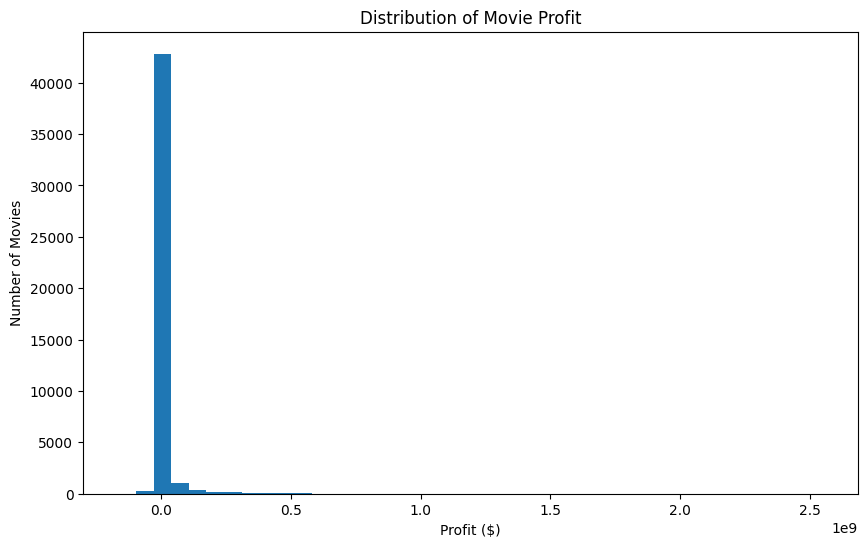

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["profit"], bins=40)

plt.title("Distribution of Movie Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Number of Movies")

plt.show()

## Key Findings


- 7,194 movies had production budgets over $1 million.
- 176 movies were highly rated, with an average rating above 8 and more than 20 votes.
- The dataset included 89 unique original languages.
- 344 contained missing values in the selected analysis fields
- Average movie profits was apporximetly 7.04 million dollars.


## Skills Demonstrated

- Python
- Pandas
- NumPy
- Data Cleaning
- Missing-Value Handling
- Data Transformation
- Exploratory Data Analysis
- Data Visualization